In [ ]:
import sys
sys.path.append('../')

import numpy as np
import pandas as pd
import lightgbm as lgb
import optuna
import warnings
from src.mypackage.data_preparation import prepare_lightgbm_data, prepare_statistical_data
from src.mypackage.forecasting import lightgbm_forecast
from src.mypackage.evaluation import print_metrics
from src.mypackage.visualization import plot_forecast
from src.mypackage.utils import set_seed, SEED

warnings.filterwarnings("ignore")
set_seed(SEED)

In [ ]:
df = pd.read_csv("../data/raw/PJME_hourly.csv")
data = prepare_lightgbm_data(df, lags=[2, 24, 24*7], pred_len=1, shift=1)

In [ ]:
X_train, y_train, X_test, y_test = data['X_train'].iloc[:, 1:], data['y_train'].reshape(-1), data['X_test'].iloc[:, 1:], data['y_test'].reshape(-1)
X_train, X_valid = X_train[:-24*365], X_train[-24*365:]
y_train, y_valid = y_train[:-24*365], y_train[-24*365:]

def objective(trial):
    params = {
        "objective": "regression",
        "metric": "rmse",
        "verbosity": -1,
        "bagging_freq": 1,
        "feature_pre_filter": False,
        "seed": SEED,

        # 探索対象
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.5, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 300),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 100),
        "max_depth": trial.suggest_int("max_depth", -1, 20),
        "lambda_l1": trial.suggest_float("lambda_l1", 0.0, 10.0),
        "lambda_l2": trial.suggest_float("lambda_l2", 0.0, 10.0),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.5, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.5, 1.0),
    }

    callbacks = [
        lgb.early_stopping(stopping_rounds=10, verbose=False),
        # lgb.log_evaluation(period=100)
    ]

    ds_train = lgb.Dataset(data=X_train, label=y_train)
    ds_valid = lgb.Dataset(data=X_valid, label=y_valid, reference=ds_train)
    model = lgb.train(params, ds_train, num_boost_round=1000, 
                      valid_sets=[ds_valid], callbacks=callbacks)
    best_rmse = model.best_score["valid_0"]["rmse"]
    best_iteration = model.best_iteration
    trial.set_user_attr("best_iteration", best_iteration)
    return best_rmse   

In [ ]:
sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction="minimize", sampler=sampler)
study.optimize(objective, n_trials=50)
print(study.best_params) 

[I 2026-07-11 15:43:24,466] A new study created in memory with name: no-name-2b5d9b06-cd91-47d7-bc72-678f8f695e35
[I 2026-07-11 15:43:43,099] Trial 0 finished with value: 273.23838219255725 and parameters: {'learning_rate': 0.043284502212938815, 'num_leaves': 287, 'min_data_in_leaf': 76, 'max_depth': 12, 'lambda_l1': 1.5601864044243652, 'lambda_l2': 1.5599452033620265, 'feature_fraction': 0.5290418060840998, 'bagging_fraction': 0.9330880728874675}. Best is trial 0 with value: 273.23838219255725.
[I 2026-07-11 15:43:52,161] Trial 1 finished with value: 271.7069329577125 and parameters: {'learning_rate': 0.10502105436744279, 'num_leaves': 218, 'min_data_in_leaf': 11, 'max_depth': 20, 'lambda_l1': 8.324426408004218, 'lambda_l2': 2.1233911067827616, 'feature_fraction': 0.5909124836035503, 'bagging_fraction': 0.5917022549267169}. Best is trial 1 with value: 271.7069329577125.
[I 2026-07-11 15:43:59,269] Trial 2 finished with value: 300.70980583778993 and parameters: {'learning_rate': 0.0328

{'learning_rate': 0.031801890790700754, 'num_leaves': 178, 'min_data_in_leaf': 33, 'max_depth': 15, 'lambda_l1': 4.126807888453963, 'lambda_l2': 3.56930661602198, 'feature_fraction': 0.9124723863284004, 'bagging_fraction': 0.8106746126819561}


In [37]:
# 再学習
ds_train = lgb.Dataset(data=data["X_train"].iloc[:, 1:], label=data["y_train"].reshape(-1))
model = lgb.train(study.best_params, ds_train, num_boost_round= study.best_trial.user_attrs["best_iteration"])
model.save_model("../models/lightgbm_best_model.txt")

In [ ]:
# モデルの読み込み
with open("../models/lightgbm_best_model.txt", "r") as f:
    model_str = f.read()

model = lgb.Booster(model_str=model_str)

In [ ]:
y_test = data["y_test"].reshape(-1)[np.isnan(data["y_test"].reshape(-1)) == False]
_, tmp = prepare_statistical_data(df)
timesteps = tmp["Datetime"].copy()[:len(y_test)]
del tmp

y_pred_day = lightgbm_forecast(model, data, pred_len=24)[:len(y_test)]
y_pred_week = lightgbm_forecast(model, data, pred_len=24*7)[:len(y_test)]
y_pred_month = lightgbm_forecast(model, data, pred_len=24*30)[:len(y_test)]
y_pred_year = lightgbm_forecast(model, data, pred_len=24*365)[:len(y_test)]

print_metrics(y_test, y_pred_day, "GBDT Forecast (1 Day)")
print_metrics(y_test, y_pred_week, "GBDT Forecast (1 Week)")
print_metrics(y_test, y_pred_month, "GBDT Forecast (1 Month)")
print_metrics(y_test, y_pred_year, "GBDT Forecast (1 Year)")

GBDT Forecast (1 Day):
MAE: 1794.36
RMSE: 2507.95
MAPE: 5.54%

GBDT Forecast (1 Week):
MAE: 2845.72
RMSE: 3932.56
MAPE: 8.81%

GBDT Forecast (1 Month):
MAE: 3121.12
RMSE: 4176.23
MAPE: 9.53%

GBDT Forecast (1 Year):
MAE: 3442.30
RMSE: 4861.59
MAPE: 10.14%



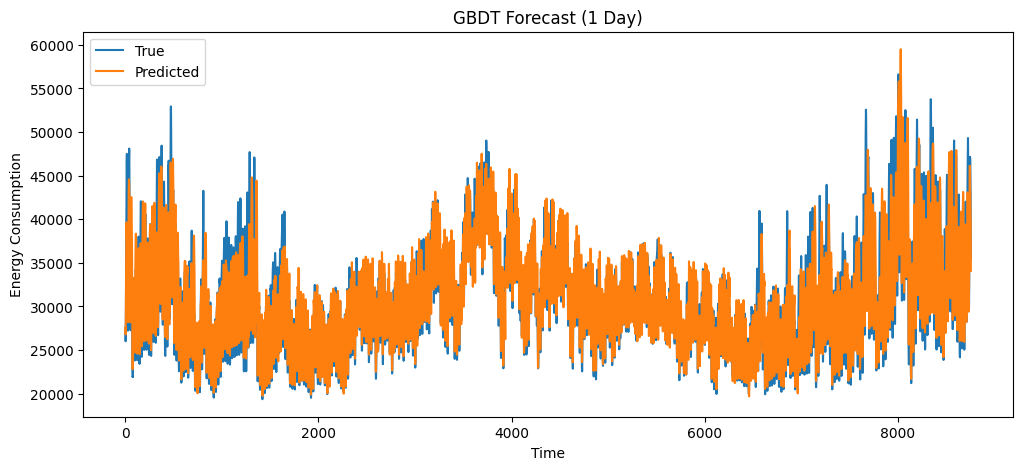

In [ ]:
plot_forecast(y_test, y_pred_day, timesteps, "GBDT Forecast (1 Day)")

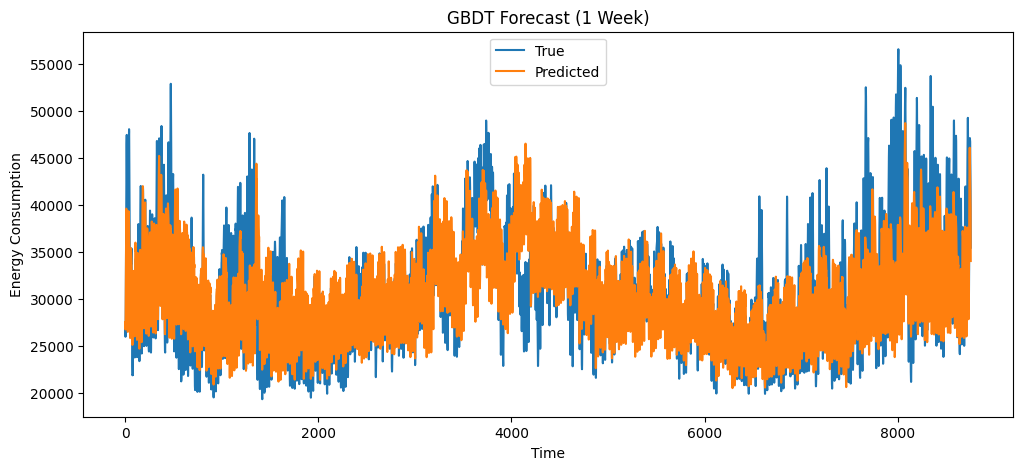

In [ ]:
plot_forecast(y_test, y_pred_week, timesteps, "GBDT Forecast (1 Week)")

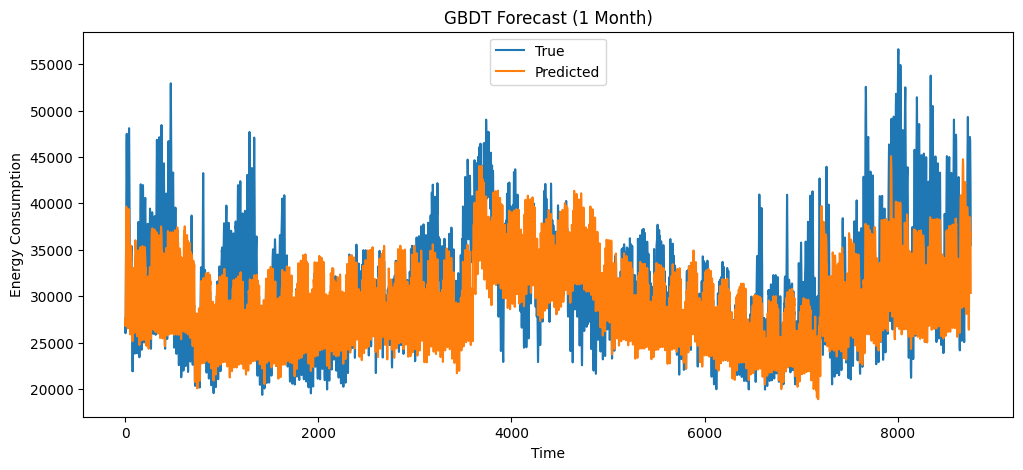

In [ ]:
plot_forecast(y_test, y_pred_month, timesteps, "GBDT Forecast (1 Month)")

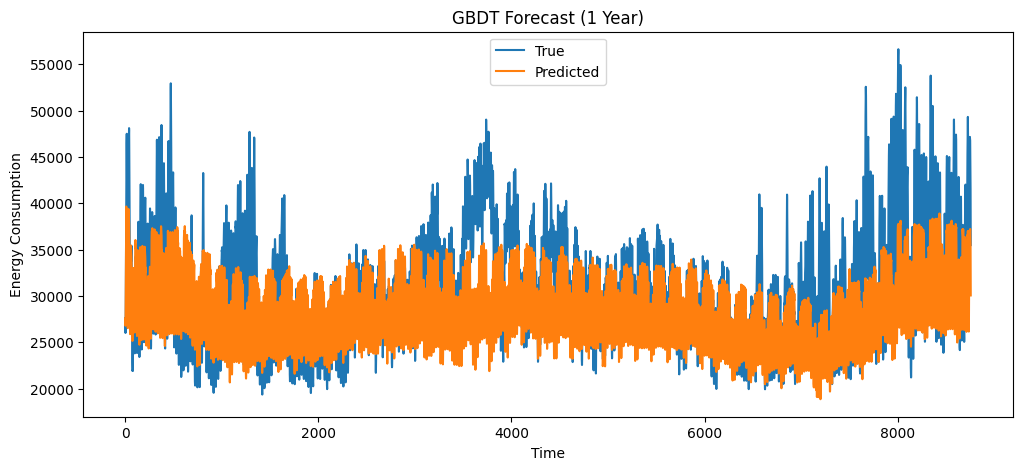

In [ ]:
plot_forecast(y_test, y_pred_year, timesteps, "GBDT Forecast (1 Year)")